# Peak RSS Memory Benchmark: ffocp_eq vs cvxpylayer

This notebook compares the peak RSS (Resident Set Size) memory usage between `ffocp_eq` and `cvxpylayer` across problem sizes.

- batch_size = 8
- ydim ∈ {100, 200, …, 1000}
- Only **one iteration** per ydim (first batch forward + backward)


In [1]:
import os
import sys
import time
import gc

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Allow `from models import ...` when running from synthetic_task/
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from models import OptModel
from data import genData
from utils_synthetic import PeakRSS, bytes_to_gb

In [ ]:
# Configuration
BATCH_SIZE = 8
SEED = 3
INPUT_DIM = 640
YDIM_LIST = list(range(100, 1001, 100))
NUM_SAMPLES = 2000
LEARNING_RATE = 0.001

# Hyperparameters for ffocp_eq
ALPHA = 100
DUAL_CUTOFF = 1e-3
SLACK_TOL = 1e-8
BACKWARD_EPS = 1e-3

# Device
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")
print(f"ydim values to benchmark: {YDIM_LIST}")

Using device: cpu
ydim values to benchmark: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


In [3]:
def set_seed(seed):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

def cleanup():
    """Clean up memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
def benchmark_method(method_name, ydim):
    """
    Benchmark a single method for initialization and first iteration peak RSS.
    
    Args:
        method_name: 'ffocp_eq' or 'cvxpylayer'
        ydim: dimension of the optimization variable
    
    Returns:
        dict: Contains init_peak_rss, forward_peak_rss, backward_peak_rss (all in GB)
    """
    cleanup()
    set_seed(SEED)
    
    results = {'ydim': ydim, 'method': method_name}
    
    # Generate data
    train_loader, test_loader = genData(device, INPUT_DIM, ydim, NUM_SAMPLES, BATCH_SIZE)
    
    # Measure initialization peak RSS
    with PeakRSS(include_children=True, interval=0.0001) as m_init:
        model = OptModel(
            INPUT_DIM, ydim, 
            layer_type=method_name, 
            constraint_learnable=False, 
            batch_size=BATCH_SIZE, 
            device=device, 
            alpha=ALPHA, 
            dual_cutoff=DUAL_CUTOFF, 
            slack_tol=SLACK_TOL, 
            backward_eps=BACKWARD_EPS, 
            is_QP=True
        ).to(device)
    
    results['init_peak_rss_gb'] = bytes_to_gb(m_init.peak)
    
    # Setup optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0)
    loss_fn = torch.nn.MSELoss()
    
    # Get first batch
    x, y = next(iter(train_loader))
    
    model.train()
    
    # Measure forward pass peak RSS
    with PeakRSS(include_children=True, interval=0.0001) as m_fwd:
        start_fwd = time.time()
        z, y_pred = model(x)
        forward_time = time.time() - start_fwd
    
    results['forward_peak_rss_gb'] = bytes_to_gb(m_fwd.peak)
    results['forward_time'] = forward_time
    
    # Compute loss
    ts_loss = loss_fn(y_pred, y)
    df_loss = torch.mean(y * z)
    loss = df_loss
    
    # Measure backward pass peak RSS
    with PeakRSS(include_children=True, interval=0.0001) as m_bwd:
        start_bwd = time.time()
        loss.backward()
        backward_time = time.time() - start_bwd
    
    results['backward_peak_rss_gb'] = bytes_to_gb(m_bwd.peak)
    results['backward_time'] = backward_time
    results['total_iter_time'] = forward_time + backward_time
    
    # Cleanup
    del model, optimizer, train_loader, test_loader
    cleanup()
    
    return results

## Run Benchmarks for All ydim Values

In [5]:
# Run benchmarks for all ydim values
all_results = []

for ydim in YDIM_LIST:
    print(f"\n{'='*60}")
    print(f"Benchmarking ydim={ydim}")
    print(f"{'='*60}")
    
    # Benchmark ffocp_eq
    print(f"  Running ffocp_eq...")
    ffocp_result = benchmark_method('ffocp_eq', ydim)
    all_results.append(ffocp_result)
    print(f"    Init RSS: {ffocp_result['init_peak_rss_gb']:.4f} GB, "
          f"Forward RSS: {ffocp_result['forward_peak_rss_gb']:.4f} GB, "
          f"Backward RSS: {ffocp_result['backward_peak_rss_gb']:.4f} GB")
    
    # Benchmark cvxpylayer
    print(f"  Running cvxpylayer...")
    cvxpy_result = benchmark_method('cvxpylayer', ydim)
    all_results.append(cvxpy_result)
    print(f"    Init RSS: {cvxpy_result['init_peak_rss_gb']:.4f} GB, "
          f"Forward RSS: {cvxpy_result['forward_peak_rss_gb']:.4f} GB, "
          f"Backward RSS: {cvxpy_result['backward_peak_rss_gb']:.4f} GB")

print(f"\n{'='*60}")
print("All benchmarks completed!")
print(f"{'='*60}")


Benchmarking ydim=100
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 0.3490 GB, Forward RSS: 0.3977 GB, Backward RSS: 0.4037 GB
  Running cvxpylayer...


/nethome/zzhao628/anaconda3/envs/bilevel/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain.py:250: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(


    Init RSS: 0.5497 GB, Forward RSS: 0.5671 GB, Backward RSS: 0.5808 GB

Benchmarking ydim=200
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 0.5896 GB, Forward RSS: 0.5896 GB, Backward RSS: 0.5945 GB
  Running cvxpylayer...
    Init RSS: 1.2633 GB, Forward RSS: 1.2686 GB, Backward RSS: 1.3053 GB

Benchmarking ydim=300
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 1.3261 GB, Forward RSS: 1.3312 GB, Backward RSS: 1.3318 GB
  Running cvxpylayer...
    Init RSS: 2.6546 GB, Forward RSS: 2.6542 GB, Backward RSS: 2.7367 GB

Benchmarking ydim=400
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 2.7676 GB, Forward RSS: 2.7676 GB, Backward RSS: 2.7688 GB
  Running cvxpylayer...
    Init RSS: 4.3196 GB, Forward RSS: 4.3207 GB, Backward RSS: 4.5112 GB

Benchmarking ydim=500
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward 

## Results Table

In [7]:
# Create DataFrame from results
df = pd.DataFrame(all_results)

# Pivot for easier comparison
df_ffocp = df[df['method'] == 'ffocp_eq'].set_index('ydim')
df_cvxpy = df[df['method'] == 'cvxpylayer'].set_index('ydim')

# Display full results table
print("Full Results:")
df

Full Results:


,ydim,method,init_peak_rss_gb,forward_peak_rss_gb,forward_time,backward_peak_rss_gb,backward_time,total_iter_time
0,100,ffocp_eq,0.348972,0.397724,0.528566,0.403728,0.380316,0.908882
1,100,cvxpylayer,0.549717,0.567085,0.127400,0.580765,0.060595,0.187995
2,200,ffocp_eq,0.589577,0.589577,0.340160,0.594540,0.384508,0.724669
3,200,cvxpylayer,1.263287,1.268631,0.258988,1.305305,0.099989,0.358977
4,300,ffocp_eq,1.326054,1.331150,0.544590,1.331795,0.587797,1.132386
5,300,cvxpylayer,2.654556,2.654190,0.657000,2.736717,0.155404,0.812403
6,400,ffocp_eq,2.767574,2.767582,0.805968,2.768848,0.830708,1.636676
7,400,cvxpylayer,4.319622,4.320667,1.105377,4.511200,0.283430,1.388807
8,500,ffocp_eq,4.510212,4.510212,1.029766,4.512943,1.151186,2.180952
9,500,cvxpylayer,7.034058,7.248985,1.784435,7.328690,0.315412,2.099847


## Visualization: Peak RSS vs ydim

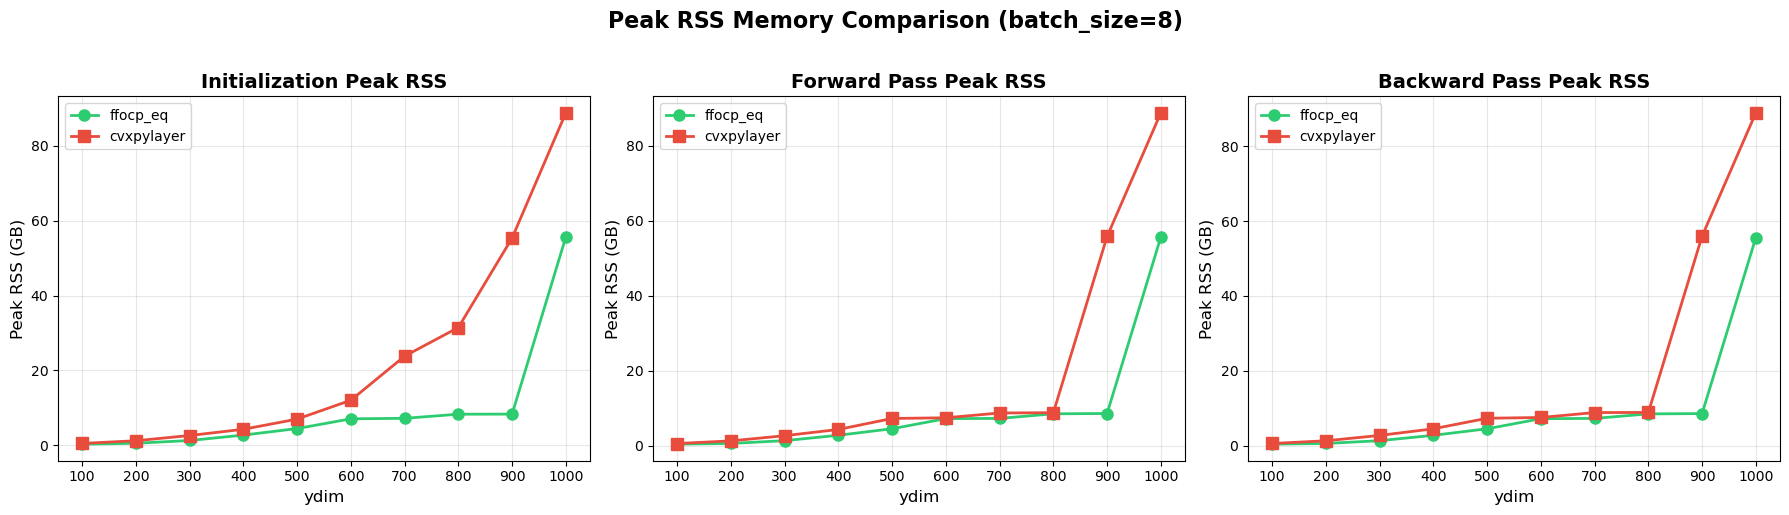

In [8]:
# Create visualization with 3 subplots for memory metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colors
color_ffocp = '#2ecc71'  # Green
color_cvxpy = '#e74c3c'  # Red

# Plot 1: Initialization Peak RSS
axes[0].plot(YDIM_LIST, df_ffocp['init_peak_rss_gb'].values, 'o-', 
             color=color_ffocp, linewidth=2, markersize=8, label='ffocp_eq')
axes[0].plot(YDIM_LIST, df_cvxpy['init_peak_rss_gb'].values, 's-', 
             color=color_cvxpy, linewidth=2, markersize=8, label='cvxpylayer')
axes[0].set_xlabel('ydim', fontsize=12)
axes[0].set_ylabel('Peak RSS (GB)', fontsize=12)
axes[0].set_title('Initialization Peak RSS', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(YDIM_LIST)

# Plot 2: Forward Pass Peak RSS
axes[1].plot(YDIM_LIST, df_ffocp['forward_peak_rss_gb'].values, 'o-', 
             color=color_ffocp, linewidth=2, markersize=8, label='ffocp_eq')
axes[1].plot(YDIM_LIST, df_cvxpy['forward_peak_rss_gb'].values, 's-', 
             color=color_cvxpy, linewidth=2, markersize=8, label='cvxpylayer')
axes[1].set_xlabel('ydim', fontsize=12)
axes[1].set_ylabel('Peak RSS (GB)', fontsize=12)
axes[1].set_title('Forward Pass Peak RSS', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(YDIM_LIST)

# Plot 3: Backward Pass Peak RSS
axes[2].plot(YDIM_LIST, df_ffocp['backward_peak_rss_gb'].values, 'o-', 
             color=color_ffocp, linewidth=2, markersize=8, label='ffocp_eq')
axes[2].plot(YDIM_LIST, df_cvxpy['backward_peak_rss_gb'].values, 's-', 
             color=color_cvxpy, linewidth=2, markersize=8, label='cvxpylayer')
axes[2].set_xlabel('ydim', fontsize=12)
axes[2].set_ylabel('Peak RSS (GB)', fontsize=12)
axes[2].set_title('Backward Pass Peak RSS', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(YDIM_LIST)

plt.suptitle(f'Peak RSS Memory Comparison (batch_size={BATCH_SIZE})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('peakrss_vs_ydim_memory.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization: Execution Time vs ydim

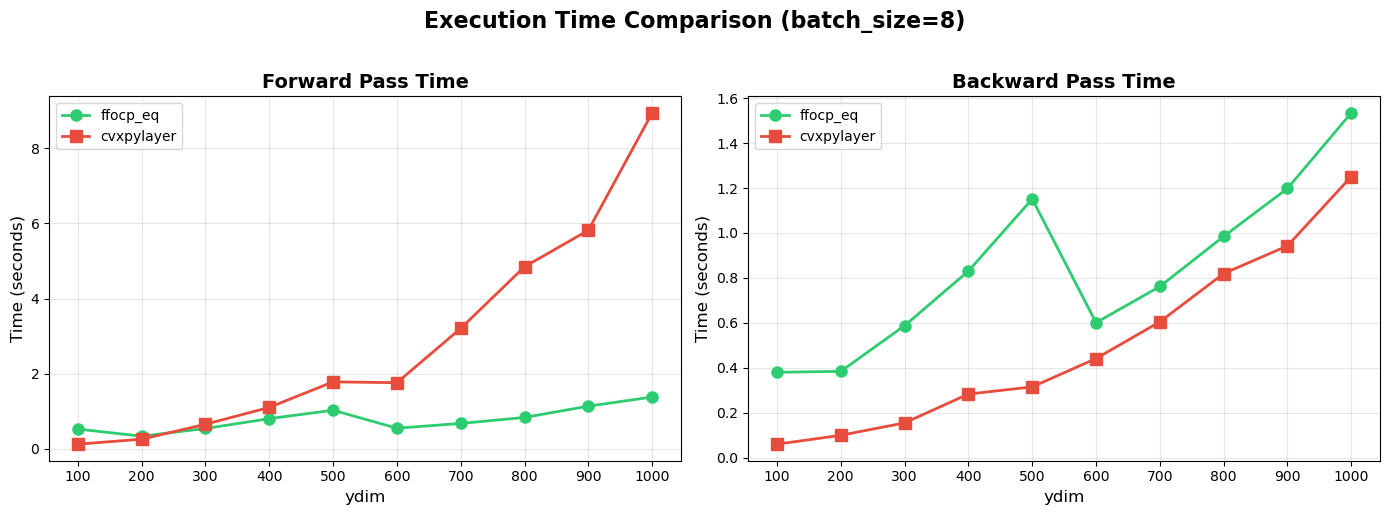

In [9]:
# Create visualization for time metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Forward Time
axes[0].plot(YDIM_LIST, df_ffocp['forward_time'].values, 'o-', 
             color=color_ffocp, linewidth=2, markersize=8, label='ffocp_eq')
axes[0].plot(YDIM_LIST, df_cvxpy['forward_time'].values, 's-', 
             color=color_cvxpy, linewidth=2, markersize=8, label='cvxpylayer')
axes[0].set_xlabel('ydim', fontsize=12)
axes[0].set_ylabel('Time (seconds)', fontsize=12)
axes[0].set_title('Forward Pass Time', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(YDIM_LIST)

# Plot 2: Backward Time
axes[1].plot(YDIM_LIST, df_ffocp['backward_time'].values, 'o-', 
             color=color_ffocp, linewidth=2, markersize=8, label='ffocp_eq')
axes[1].plot(YDIM_LIST, df_cvxpy['backward_time'].values, 's-', 
             color=color_cvxpy, linewidth=2, markersize=8, label='cvxpylayer')
axes[1].set_xlabel('ydim', fontsize=12)
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('Backward Pass Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(YDIM_LIST)

plt.suptitle(f'Execution Time Comparison (batch_size={BATCH_SIZE})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('peakrss_vs_ydim_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Ratio Analysis (cvxpylayer / ffocp_eq)

In [10]:
# Calculate ratios (cvxpylayer / ffocp_eq)
ratio_df = pd.DataFrame({
    'ydim': YDIM_LIST,
    'Init RSS Ratio': df_cvxpy['init_peak_rss_gb'].values / df_ffocp['init_peak_rss_gb'].values,
    'Forward RSS Ratio': df_cvxpy['forward_peak_rss_gb'].values / df_ffocp['forward_peak_rss_gb'].values,
    'Backward RSS Ratio': df_cvxpy['backward_peak_rss_gb'].values / df_ffocp['backward_peak_rss_gb'].values,
    'Forward Time Ratio': df_cvxpy['forward_time'].values / df_ffocp['forward_time'].values,
    'Backward Time Ratio': df_cvxpy['backward_time'].values / df_ffocp['backward_time'].values,
})

print("Ratio Analysis (cvxpylayer / ffocp_eq):")
print("Values > 1 mean cvxpylayer uses more memory/time than ffocp_eq")
print()
ratio_df

Ratio Analysis (cvxpylayer / ffocp_eq):
Values > 1 mean cvxpylayer uses more memory/time than ffocp_eq



,ydim,Init RSS Ratio,Forward RSS Ratio,Backward RSS Ratio,Forward Time Ratio,Backward Time Ratio
0,100,1.575245,1.425826,1.438503,0.241030,0.159328
1,200,2.142701,2.151766,2.195489,0.761369,0.260044
2,300,2.001847,1.993907,2.054909,1.206412,0.264383
3,400,1.560797,1.561170,1.629269,1.371490,0.341191
4,500,1.559585,1.607238,1.623927,1.732855,0.273989
5,600,1.698400,1.030693,1.045123,3.192654,0.734547
6,700,3.289820,1.199459,1.213202,4.727681,0.793758
7,800,3.771595,1.034837,1.045514,5.781469,0.832179
8,900,6.616321,6.507054,6.530078,5.110278,0.786911
9,1000,1.595738,1.595737,1.599605,6.471095,0.815420


In [11]:
# Summary statistics
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)

print("\nAverage Ratios (cvxpylayer / ffocp_eq) across all ydim values:")
print(f"  - Initialization RSS: {ratio_df['Init RSS Ratio'].mean():.2f}x")
print(f"  - Forward Pass RSS:   {ratio_df['Forward RSS Ratio'].mean():.2f}x")
print(f"  - Backward Pass RSS:  {ratio_df['Backward RSS Ratio'].mean():.2f}x")
print(f"  - Forward Time:       {ratio_df['Forward Time Ratio'].mean():.2f}x")
print(f"  - Backward Time:      {ratio_df['Backward Time Ratio'].mean():.2f}x")

print("\nAt largest ydim (1000):")
print(f"  ffocp_eq:")
print(f"    - Init RSS:     {df_ffocp.loc[1000, 'init_peak_rss_gb']:.4f} GB")
print(f"    - Forward RSS:  {df_ffocp.loc[1000, 'forward_peak_rss_gb']:.4f} GB")
print(f"    - Backward RSS: {df_ffocp.loc[1000, 'backward_peak_rss_gb']:.4f} GB")
print(f"  cvxpylayer:")
print(f"    - Init RSS:     {df_cvxpy.loc[1000, 'init_peak_rss_gb']:.4f} GB")
print(f"    - Forward RSS:  {df_cvxpy.loc[1000, 'forward_peak_rss_gb']:.4f} GB")
print(f"    - Backward RSS: {df_cvxpy.loc[1000, 'backward_peak_rss_gb']:.4f} GB")

SUMMARY STATISTICS

Average Ratios (cvxpylayer / ffocp_eq) across all ydim values:
  - Initialization RSS: 2.58x
  - Forward Pass RSS:   2.01x
  - Backward Pass RSS:  2.04x
  - Forward Time:       3.06x
  - Backward Time:      0.53x

At largest ydim (1000):
  ffocp_eq:
    - Init RSS:     55.5935 GB
    - Forward RSS:  55.5935 GB
    - Backward RSS: 55.5935 GB
  cvxpylayer:
    - Init RSS:     88.7127 GB
    - Forward RSS:  88.7127 GB
    - Backward RSS: 88.9277 GB


In [12]:
# Save results to CSV
df.to_csv('peakrss_benchmark_results.csv', index=False)
ratio_df.to_csv('peakrss_benchmark_ratios.csv', index=False)
print("Results saved to 'peakrss_benchmark_results.csv' and 'peakrss_benchmark_ratios.csv'")

Results saved to 'peakrss_benchmark_results.csv' and 'peakrss_benchmark_ratios.csv'
